# 18 — Análisis de una liga (Eredivisie): plantillas, porteros, impacto en cancha y fantasy

Hay **un notebook por liga** (`18_analisis_liga_<liga>.ipynb`), todos con el mismo código: solo cambian el parámetro
`LIGA` (primera celda de código) y los textos de interpretación, que se escriben después de ver los resultados de
cada liga. Las figuras se guardan con el nombre de la liga en `output/figures/ligas/`, así que no se pisan. La misma
lógica alimenta la página web del análisis (`scripts/export_analisis_liga.py`).

**Datos**: el dataset unificado de la Fase 19 — tabla estándar + `playingtime` + `keepers` de FBref, 16 temporadas
(2010-11 a 2025-26). Se usa en dos niveles:

- **jugador-equipo-temporada** (`filas`) para todo lo que es de un *equipo*: si un jugador se fue a mitad de
  temporada, sus minutos cuentan para cada uno de sus dos equipos;
- **jugador-temporada** (`jt`) para todo lo que es de un *jugador*.

**Secciones**

1. **Plantillas y rotación** — cuántos jugadores usa cada equipo, qué tan concentrados están los minutos, edad y
   extranjeros, temporada por temporada.
2. **Porteros** — % de paradas, porterías a cero y goles recibidos, de la liga y de cada portero.
3. **Impacto en cancha** — ¿qué dicen el +/− y el "con/sin él" de un jugador? (solo desde 2014-15).
4. **Fantasy y dependencia** — cuánto depende cada equipo de su goleador y de su mejor jugador fantasy.

**Lo que conviene recordar al leer**: una celda vacía es "FBref no tiene el dato" (no cero). En esta liga-temporada
pueden faltar datos según la época — el diccionario `data/processed/jugadores_temporada_2010_2026_diccionario.csv`
dice desde cuándo existe cada columna. Toda la lógica está en `futbol_bd/liga.py` (probada en `tests/test_liga.py`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import estilo, fantasy, liga, plantillas

# ======================================================================================================================
LIGA = "Eredivisie"
# ======================================================================================================================

SLUG = LIGA.lower().replace(" ", "_")
FIGURAS = RAIZ / "output" / "figures" / "ligas"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 0. Los datos de la liga

Se construyen las dos tablas con las funciones del paquete (las mismas que generan el CSV unificado) y se agrega el
resumen por equipo-temporada (`liga.resumen_equipos`). Antes de analizar nada, un control de calidad: cada equipo debe
sumar ≈ partidos × 990 minutos (11 jugadores × 90 minutos por partido; un poco menos si hubo expulsiones). Si faltaran
jugadores en el scrapeo, este cociente quedaría claramente por debajo de 1.

In [2]:
filas = plantillas.unir_tablas_extra(plantillas.limpiar_panel(plantillas.cargar_panel_crudo()))
jt = fantasy.puntos_fantasy(plantillas.agregar_por_temporada(filas))
# Percentil fantasy dentro de liga-temporada-posición (900+ minutos), como en el notebook 17.
jt["pct_pts_jornada"] = fantasy.percentil_en_grupo(jt, "pts_por_jornada")
filas, jt = filas[filas["league"] == LIGA], jt[jt["league"] == LIGA]
equipos = liga.resumen_equipos(filas, LIGA)
TEMPORADAS = sorted(equipos["temporada_inicio"].unique())

control = equipos.assign(cobertura_minutos=equipos["minutos"] / (equipos["pj"] * 990)).groupby("season").agg(
    equipos=("team_id", "size"), partidos_por_equipo=("pj", "median"), jugadores=("jugadores_usados", "sum"),
    cobertura_minutos_min=("cobertura_minutos", "min"), cobertura_minutos_mediana=("cobertura_minutos", "median"))
print(f"{LIGA}: {len(jt):,} jugador-temporadas, {jt['id_jugador'].nunique():,} jugadores, "
      f"{equipos['team_id'].nunique()} equipos distintos en {len(TEMPORADAS)} temporadas")
control.round(3)

Eredivisie: 7,764 jugador-temporadas, 2,905 jugadores, 29 equipos distintos en 16 temporadas


,equipos,partidos_por_equipo,jugadores,cobertura_minutos_min,cobertura_minutos_mediana
season,,,,,
2010-2011,18,34.0,488,0.993,0.997
2011-2012,18,34.0,475,0.992,0.997
2012-2013,18,34.0,469,0.991,0.996
2013-2014,18,34.0,464,0.991,0.998
2014-2015,18,34.0,480,0.993,0.998
2015-2016,18,34.0,473,0.996,0.998
2016-2017,18,34.0,484,0.994,0.998
2017-2018,18,34.0,477,0.994,0.998
2018-2019,18,34.0,478,0.991,0.997


18 equipos y 34 partidos, salvo 2019-20, que se canceló por COVID tras 25-26 jornadas; 7,764 jugador-temporadas de
2,905 jugadores en 29 clubes. Cobertura de minutos del 99.1% al 99.8%.

Además, **2018-19 no tiene paradas ni tiros a puerta** en FBref (el mismo hueco que la Liga MX): por eso la línea del
% de paradas se corta en esa temporada.

## 1. Plantillas y rotación

Cuatro medidas por equipo-temporada (definidas en `liga.resumen_equipos`):

- **jugadores usados**: cuántos jugadores tuvieron minutos;
- **jugadores para el 80% de los minutos**: concentración. Con un once fijo serían ~11-12; si el técnico rota, más.
  Es más robusta que "jugadores usados", que sube con cualquier debutante de 5 minutos;
- **edad ponderada por minutos**: la edad de *quien juega*, no la de la lista;
- **% de minutos de extranjeros** (nacionalidad deportiva según FBref, ver `liga.NACIONALES`).

La figura muestra, por temporada, la **mediana** de los equipos (línea) y el rango donde está la mitad central de los
equipos (banda, percentiles 25-75). Mediana y no promedio: un equipo con una temporada rara no mueve la tendencia.

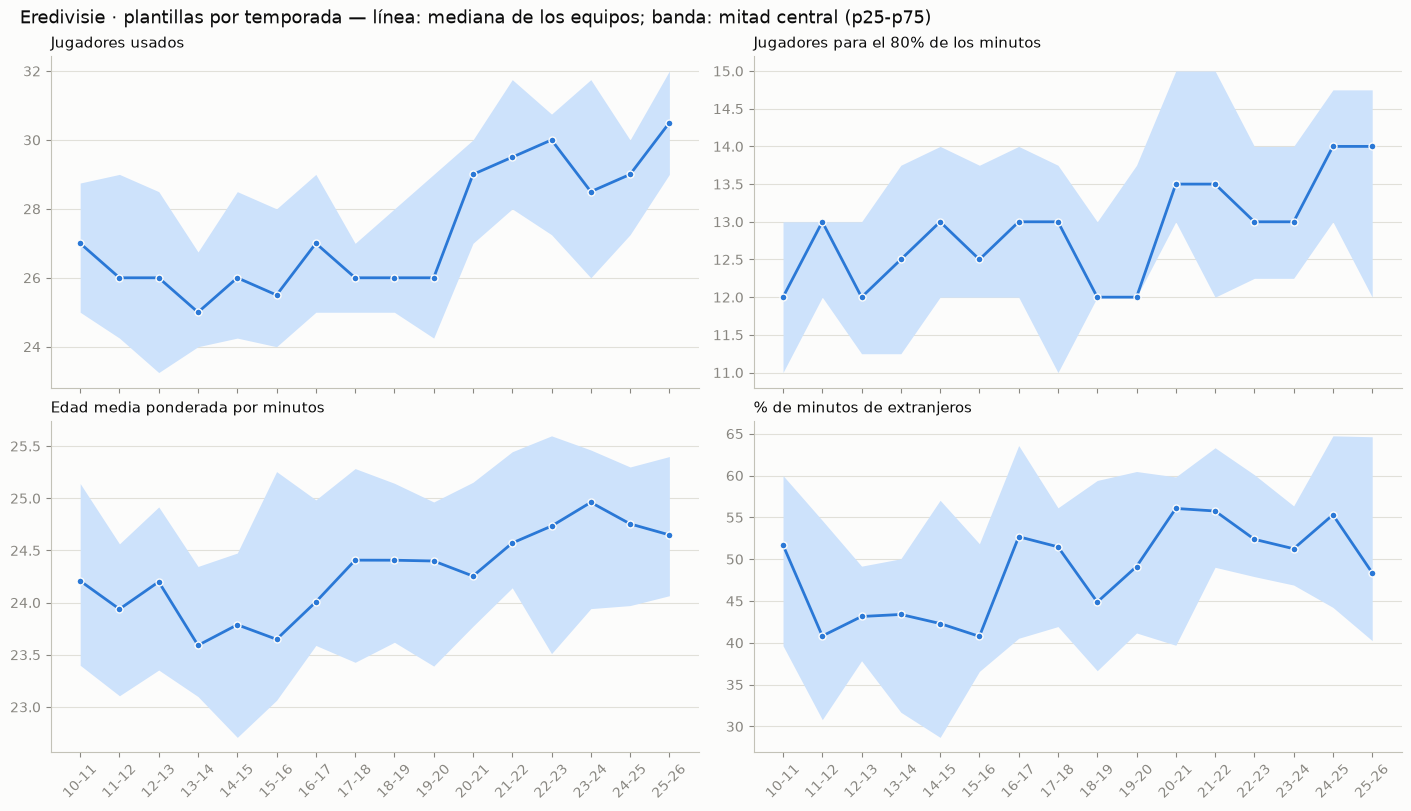

In [3]:
metricas = {"jugadores_usados": "Jugadores usados", "jugadores_80pct": "Jugadores para el 80% de los minutos",
            "edad_ponderada": "Edad media ponderada por minutos", "pct_min_extranjeros": "% de minutos de extranjeros"}
tendencia = liga.tendencia_liga(equipos, list(metricas))

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs.ravel(), metricas.items()):
    ax.fill_between(TEMPORADAS, tendencia[("p25", col)], tendencia[("p75", col)], color=estilo.AZUL_CLARO, linewidth=0)
    ax.plot(TEMPORADAS, tendencia[("mediana", col)], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
for ax in axs[1]:
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · plantillas por temporada — línea: mediana de los equipos; banda: mitad central (p25-p75)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_plantillas.png", dpi=150)
plt.show()

- **La liga más joven del panel, con diferencia**: la edad de quien juega va de 23.6 a 25.0 años, y entre el **20% y
  el 33.6% de los minutos** son de jugadores de 21 años o menos (en la Premier son 6-12.7%).
- **La rotación más concentrada**: 12-14 jugadores para el 80% de los minutos, el rango más bajo de las siete ligas,
  aunque subió a 13.5-14 desde 2020-21.
- **Extranjeros**: entre 40.8% y 56.1% de los minutos, sin una tendencia clara.

In [4]:
# Los extremos de todo el periodo: los equipos que más rotaron (más jugadores para cubrir el 80% de los minutos) y los
# que menos. Se muestra también el resultado (puntos por partido) para ver si rotar se asocia con ganar o perder.
columnas = ["season", "equipo", "jugadores_usados", "jugadores_80pct", "edad_ponderada", "pct_min_extranjeros", "ppg"]
print("Más rotación:")
display(equipos.nlargest(6, "jugadores_80pct")[columnas].round(1))
print("Menos rotación:")
display(equipos.nsmallest(6, "jugadores_80pct")[columnas].round(1))
rho = spearmanr(equipos["jugadores_80pct"], equipos["ppg"], nan_policy="omit").statistic
print(f"Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): {rho:.2f}")

Más rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
187,2020-2021,ADO Den Haag,37,19,24.0,39.1,0.6
229,2022-2023,Groningen,36,18,22.5,70.7,0.5
21,2011-2012,Utrecht,33,17,24.5,55.0,1.3
282,2025-2026,Heracles Almelo,32,17,25.9,54.6,0.6
81,2014-2015,NAC Breda,30,16,24.6,42.6,0.8
95,2015-2016,Roda JC,33,16,25.9,47.4,1.0


Menos rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
13,2010-2011,Heracles Almelo,24,10,26.3,40.8,1.4
38,2012-2013,Vitesse,22,10,23.2,55.3,1.9
63,2013-2014,Twente,26,10,22.5,55.9,1.9
102,2015-2016,Heracles Almelo,22,10,24.9,41.2,1.5
158,2018-2019,PSV,26,10,23.7,43.3,2.4
164,2019-2020,Heerenveen,24,10,22.2,45.8,1.3


Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): -0.38


Rotar se asocia con perder (**−0.38**): ADO Den Haag 2020-21 (19 jugadores para el 80% de los minutos, 0.6 puntos por
partido) y Groningen 2022-23 (18, 0.5) son los extremos. Los que menos rotaron: Heracles 2010-11 y 2015-16, Vitesse
2012-13 (10 jugadores, 1.9) y el **PSV 2018-19** (10 jugadores, 2.4 puntos por partido).

## 2. Porteros

Primero la liga completa: % de paradas (paradas / tiros a puerta recibidos), goles recibidos por partido y % de
partidos con portería a cero, sumando a todos los porteros antes de dividir (una tasa de la liga, no el promedio de
las tasas de cada portero). Después, cada portero en toda su carrera en la liga.

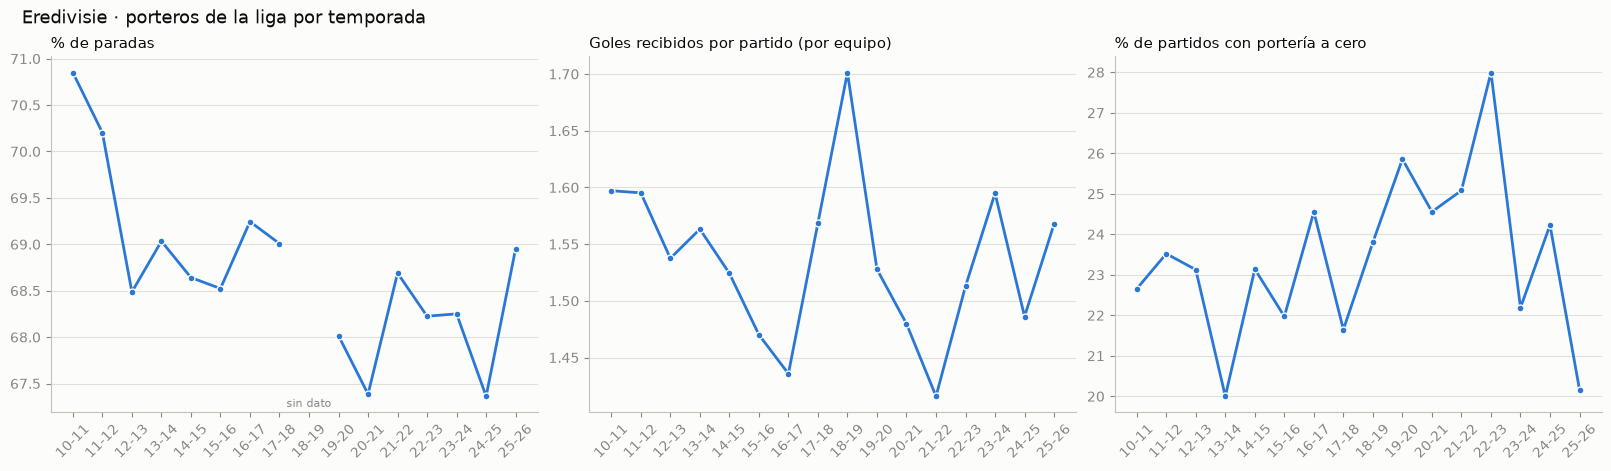

In [5]:
lp = liga.porteros_liga(jt, LIGA).reindex(TEMPORADAS)
paneles = {"pct_paradas": "% de paradas", "goles_recibidos_por_partido": "Goles recibidos por partido (por equipo)",
           "pct_porterias_cero": "% de partidos con portería a cero"}
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs, paneles.items()):
    # Una temporada sin dato queda como hueco en la línea (no se une con la siguiente como si hubiera dato).
    ax.plot(TEMPORADAS, lp[col], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    faltan = [t for t in TEMPORADAS if pd.isna(lp.loc[t, col])]
    for t in faltan:
        ax.annotate("sin dato", (t, ax.get_ylim()[0]), xytext=(0, 4), textcoords="offset points", ha="center",
                    fontsize=8, color=estilo.TENUE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · porteros de la liga por temporada", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_porteros_liga.png", dpi=150)
plt.show()

- **% de paradas**: es la línea más plana de las siete ligas (70.9% en 2010-11, 69.0% en 2025-26), pero recuerda que
  2018-19 no tiene dato.
- **Goles recibidos por partido**: de los más altos del panel (1.42-1.70), junto con la Bundesliga.
- **Porterías a cero**: las más escasas (20.0% a 28.0%).

In [6]:
# Carreras completas en la liga (mínimo 9,000 minutos ≈ 100 partidos): el % de paradas de toda la carrera pondera cada
# temporada por los tiros que recibió.
carreras = liga.carrera_porteros(jt, LIGA, min_minutos=9000)
columnas = ["portero", "equipos", "desde", "hasta", "partidos", "pct_paradas", "pct_porterias_cero", "goles_recibidos_90"]
display(carreras[columnas].head(12).round(2))

# ¿El % de paradas es del portero o de su defensa? Correlación entre una temporada y la siguiente (1,500+ minutos).
porteros_jt = jt[jt["gk_games"].notna()]
r_paradas, n_paradas, _ = liga.estabilidad(porteros_jt, "gk_save_pct", minutos="gk_minutes")
r_cero, n_cero, _ = liga.estabilidad(porteros_jt, "gk_clean_sheets_pct", minutos="gk_minutes")
print(f"Estabilidad año a año — % de paradas: r = {r_paradas:.2f} ({n_paradas} pares); "
      f"% porterías a cero: r = {r_cero:.2f} ({n_cero} pares)")

,portero,equipos,desde,hasta,partidos,pct_paradas,pct_porterias_cero,goles_recibidos_90
id_jugador,,,,,,,,
04ac8285,Jasper Cillessen,NEC Nijmegen / Ajax,2010,2025,200.0,76.36,35.00,1.08
e9c0c1b2,André Onana,Ajax,2016,2021,148.0,74.35,39.86,0.85
fdc67d9a,Nick Olij,Sparta R. / PSV,2022,2025,101.0,73.42,26.73,1.25
be855308,Sergio Padt,Groningen,2014,2020,228.0,73.00,26.75,1.32
f352799f,Nick Marsman,Twente / Utrecht / Feyenoord,2011,2020,137.0,72.40,27.74,1.20
ff7fc669,Bram Castro,Heracles Almelo,2014,2017,114.0,72.09,19.30,1.61
4b1793b0,Lars Unnerstall,VVV-Venlo / PSV / Twente,2017,2025,239.0,71.92,30.54,1.22
b7a7d76a,Piet Velthuizen,Vitesse / Fortuna Sittard,2010,2020,111.0,71.92,29.73,1.35
3d214e5f,Marco Bizot,Groningen / AZ Alkmaar,2012,2020,175.0,71.43,36.57,1.18


Estabilidad año a año — % de paradas: r = 0.26 (115 pares); % porterías a cero: r = 0.42 (131 pares)


Entre los 32 porteros con 100+ partidos, **Jasper Cillessen** tiene el mejor % de paradas (76.4% en 200 partidos con
NEC y Ajax) y **André Onana** las mejores porterías a cero (39.9%) y goles recibidos por 90 (0.85) en sus 148 partidos
con el Ajax.

Estabilidad año a año: % de paradas 0.26, la más baja de las siete ligas (también por el hueco de 2018-19), y
porterías a cero 0.42, de las más altas: en una liga con Ajax, PSV y Feyenoord muy por encima del resto, dejar la
portería en cero depende sobre todo del equipo.

In [7]:
# La última temporada, porteros con 900+ minutos. Y un control de calidad: goles recibidos según la tabla de porteros
# vs. goles recibidos por su equipo con él en cancha (onGA). Deberían coincidir; donde no, FBref se contradice.
ultima = jt[(jt["temporada_inicio"] == TEMPORADAS[-1]) & (jt["gk_minutes"] >= 900)]
display(ultima.sort_values("gk_save_pct", ascending=False)[
    ["player", "equipo_principal", "gk_games", "gk_save_pct", "gk_clean_sheets", "gk_goals_against",
     "on_goals_against"]].round(1))

por_temporada = liga.desacuerdo_goles_porteros(porteros_jt)
print(f"Porteros-temporada con ambos datos: {por_temporada['porteros'].sum()}; no coinciden: "
      f"{por_temporada['no_coinciden'].sum()}. Por temporada:")
display(por_temporada.set_index("temporada_inicio").T)
con_ambos = porteros_jt[porteros_jt["on_goals_against"].notna()]
difiere = con_ambos[con_ambos["gk_goals_against"] != con_ambos["on_goals_against"]]
print("Los de mayor diferencia:")
display(difiere.assign(diferencia=difiere["on_goals_against"] - difiere["gk_goals_against"])
        .reindex(columns=["player", "season", "equipo_principal", "gk_games", "gk_goals_against", "on_goals_against",
                          "diferencia"])
        .sort_values("diferencia", key=abs, ascending=False).head(5))

,player,equipo_principal,gk_games,gk_save_pct,gk_clean_sheets,gk_goals_against,on_goals_against
15202,Maarten Paes,Ajax,11.0,75.0,5.0,11.0,11.0
15165,Kayne van Oevelen,Volendam,32.0,74.5,3.0,51.0,51.0
15428,Vasilios Barkas,Utrecht,33.0,73.8,9.0,39.0,39.0
15112,Jari De Busser,Go Ahead Eagles,34.0,73.6,9.0,53.0,53.0
15340,Ronald Koeman Jr.,Telstar,33.0,73.0,5.0,53.0,53.0
15433,Vitezslav Jaros,Ajax,19.0,72.9,5.0,23.0,23.0
14975,Bernt Klaverboer,Heerenveen,29.0,72.0,5.0,44.0,44.0
15387,Stijn van Gassel,Excelsior,32.0,71.8,6.0,46.0,46.0
15226,Mattijs Branderhorst,Fortuna Sittard,24.0,69.1,3.0,42.0,42.0
15137,Joel Drommel,Sparta R.,34.0,68.2,11.0,62.0,62.0


Porteros-temporada con ambos datos: 434; no coinciden: 19. Por temporada:


temporada_inicio,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
no_coinciden,3,1,0,3,6,1,4,0,0,0,1,0
porteros,34,30,29,38,37,32,38,40,39,38,38,41


Los de mayor diferencia:


,player,season,equipo_principal,gk_games,gk_goals_against,on_goals_against,diferencia
11299,Robert Zwinkels,2017-2018,ADO Den Haag,29.0,47.0,42.0,-5.0
11015,David Jensen,2017-2018,Utrecht,33.0,56.0,52.0,-4.0
12375,Arijanet Muric,2020-2021,Willem II,14.0,22.0,26.0,4.0
9624,Diederik Boer,2014-2015,Zwolle,5.0,9.0,7.0,-2.0
9759,Kenneth Vermeer,2014-2015,Feyenoord,31.0,39.0,37.0,-2.0


En 2025-26, con 900+ minutos, encabezan Maarten Paes (Ajax, 75.0% en 11 partidos), **Kayne van Oevelen** (Volendam,
74.5% en 32) y Vasilios Barkas (Utrecht, 73.8%); los últimos son Luuk Koopmans (Fortuna Sittard, 61.1%) y Timo
Jansink (Heracles, 58.7%).

**Calidad de datos**: 0 a 4 desacuerdos por temporada entre las dos tablas de FBref, salvo 2018-19 con 6.

## 3. Impacto en cancha

FBref publica, desde 2014-15, dos medidas de "qué pasa cuando el jugador está en la cancha":

- **on-off** (`plus_minus_wowy`): goles netos de su equipo por 90 minutos con él en cancha, menos sin él;
- **puntos por partido con él** (`points_per_game`). Aquí se compara con los puntos por partido de su equipo en toda
  la temporada: `ppg_extra` = puntos con él − puntos del equipo (solo jugadores con un solo equipo esa temporada, para
  que la comparación sea limpia).

Son tentadoras como medida de "impacto", pero están muy expuestas a cosas ajenas al jugador: con quién comparte
cancha, contra quién jugó, si solo entra cuando el partido está roto. Antes de usarlas hay que probar si miden algo
**del jugador**: si fuera así, quien sale alto una temporada tendería a salir alto la siguiente. Como referencia de lo
que se ve cuando una medida sí es del jugador, se agrega una métrica individual: goles sin penal por 90 de los
delanteros.

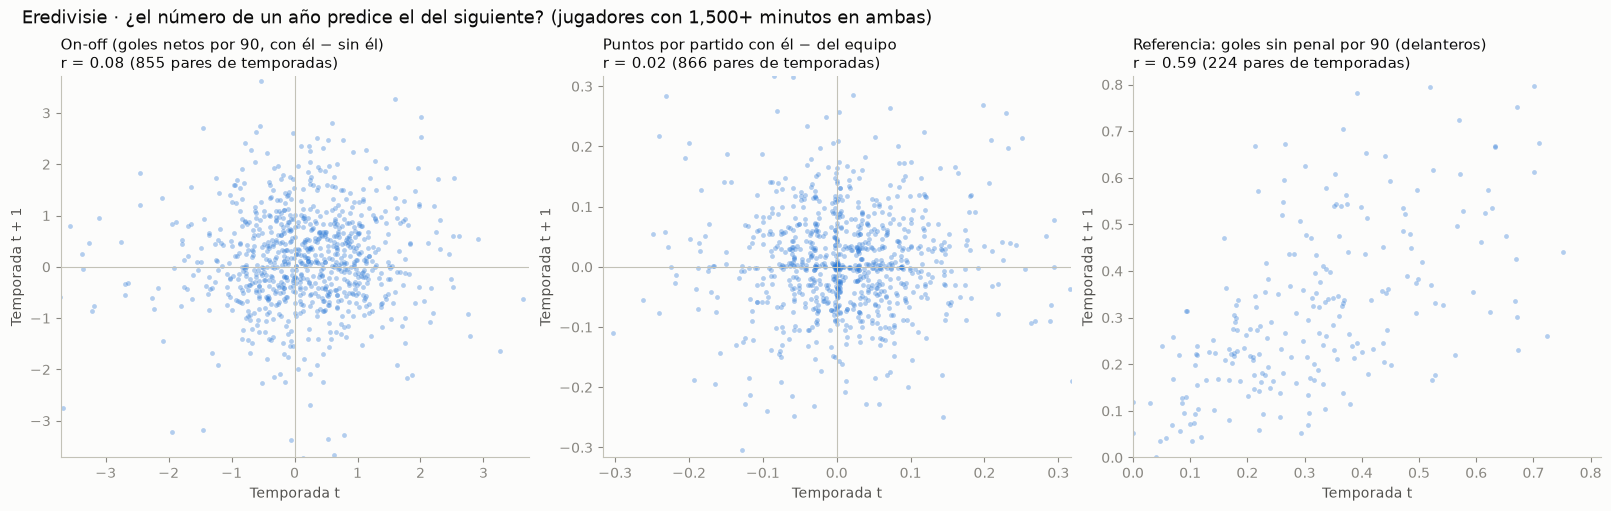

,r,pares
"On-off (goles netos por 90, con él − sin él)",0.08,855.0
Puntos por partido con él − del equipo,0.02,866.0
Referencia: goles sin penal por 90 (delanteros),0.59,224.0


In [8]:
# ppg_extra = puntos por partido con él − del equipo; solo jugadores con un equipo en la temporada (ver docstring).
jt = liga.agregar_ppg_extra(jt, equipos)

pruebas = {
    "plus_minus_wowy": ("On-off (goles netos por 90, con él − sin él)", jt),
    "ppg_extra": ("Puntos por partido con él − del equipo", jt),
    "goals_pens_per90": ("Referencia: goles sin penal por 90 (delanteros)", jt[jt["pos_principal"] == "FW"]),
}
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
resumen_estabilidad = {}
for ax, (col, (titulo, datos)) in zip(axs, pruebas.items()):
    r, n, pares = liga.estabilidad(datos, col, min_minutos=1500)
    resumen_estabilidad[titulo] = {"r": round(r, 2), "pares": n}
    ax.scatter(pares[col], pares[f"{col}_siguiente"], s=12, color=estilo.AZUL, alpha=0.35, linewidths=0)
    lim = np.nanpercentile(np.abs(pares[[col, f"{col}_siguiente"]].to_numpy()), 99)
    if col == "goals_pens_per90":
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    else:
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color=estilo.EJE, linewidth=0.8); ax.axvline(0, color=estilo.EJE, linewidth=0.8)
    ax.set_title(f"{titulo}\nr = {r:.2f} ({n} pares de temporadas)")
    ax.set_xlabel("Temporada t"); ax.set_ylabel("Temporada t + 1")
fig.suptitle(f"{LIGA} · ¿el número de un año predice el del siguiente? (jugadores con 1,500+ minutos en ambas)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_impacto_estabilidad.png", dpi=150)
plt.show()
pd.DataFrame(resumen_estabilidad).T

| Medida | Correlación año a año |
|---|---|
| On-off (goles netos con él − sin él) | **0.08** (855 pares) |
| Puntos por partido con él − del equipo | **0.02** (866 pares) |
| Referencia: goles sin penal por 90 (delanteros) | **0.59** (224 pares) |

El on-off llega aquí a su valor más alto de las siete ligas (0.08) y sigue siendo insignificante frente al 0.59 de una
medida individual. Con menos pares (855) que en las grandes ligas, la conclusión es la misma.

## 4. Fantasy y dependencia

Dos preguntas sobre cómo se reparte la producción dentro de cada equipo:

1. **Dependencia del goleador**: qué parte de los goles del equipo hizo su máximo goleador. ¿Depender de un solo
   jugador se asocia con sumar más o menos puntos?
2. **El mejor jugador fantasy de cada equipo** en la última temporada y qué parte de los puntos fantasy del equipo
   hizo (con el esquema ofensivo del notebook 17; los puntos de un jugador traspasado cuentan para su equipo
   principal).

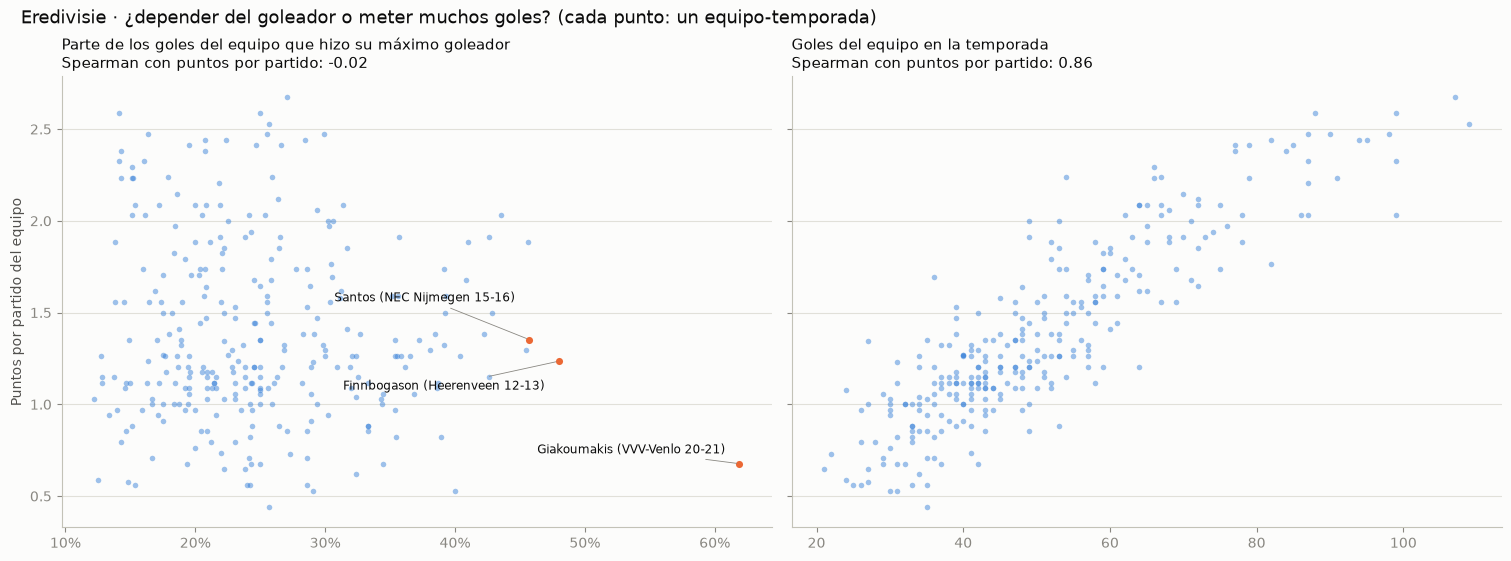

,season,equipo,goleador,goles_goleador,goles,dependencia_goleador,ppg
188,2020-2021,VVV-Venlo,Giorgos Giakoumakis,26.0,42.0,0.62,0.68
36,2012-2013,Heerenveen,Alfreð Finnbogason,24.0,50.0,0.48,1.24
107,2015-2016,NEC Nijmegen,Christian Santos,16.0,35.0,0.46,1.35
38,2012-2013,Vitesse,Wilfried Bony,31.0,68.0,0.46,1.88
23,2011-2012,Roda JC,Sanharib Malki,25.0,55.0,0.45,1.29
52,2012-2013,Feyenoord,Graziano Pellè,27.0,62.0,0.44,2.03
201,2021-2022,Vitesse,Loïs Openda,18.0,42.0,0.43,1.50
240,2023-2024,AZ Alkmaar,Vangelis Pavlidis,29.0,68.0,0.43,1.91


Mediana de la dependencia por temporada: {'2010-2011': 0.26, '2011-2012': 0.24, '2012-2013': 0.22, '2013-2014': 0.22, '2014-2015': 0.21, '2015-2016': 0.29, '2016-2017': 0.25, '2017-2018': 0.24, '2018-2019': 0.22, '2019-2020': 0.25, '2020-2021': 0.25, '2021-2022': 0.21, '2022-2023': 0.21, '2023-2024': 0.25, '2024-2025': 0.21, '2025-2026': 0.23}


In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True, constrained_layout=True)
rho_dep = spearmanr(equipos["dependencia_goleador"], equipos["ppg"], nan_policy="omit").statistic
rho_gol = spearmanr(equipos["goles"], equipos["ppg"], nan_policy="omit").statistic
for ax, (col, titulo, rho, fmt) in zip(axs, [
        ("dependencia_goleador", "Parte de los goles del equipo que hizo su máximo goleador", rho_dep, "{:.0%}"),
        ("goles", "Goles del equipo en la temporada", rho_gol, "{:.0f}")]):
    ax.scatter(equipos[col], equipos["ppg"], s=16, color=estilo.AZUL, alpha=0.45, linewidths=0)
    ax.set_title(f"{titulo}\nSpearman con puntos por partido: {rho:.2f}")
    estilo.rejilla_y(ax)
    if col == "dependencia_goleador":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        # Se resaltan los 3 equipos más dependientes. Las etiquetas se escalonan en vertical porque dos de ellos tienen
        # exactamente 1.00 punto por partido y quedarían encimadas.
        for k, (_, e) in enumerate(equipos.nlargest(3, col).iterrows()):
            ax.scatter(e[col], e["ppg"], s=44, color=estilo.NARANJA, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
                       zorder=3)
            nombre = e["goleador"] if len(e["goleador"]) <= 12 else e["goleador"].split()[-1]
            ax.annotate(f"{nombre} ({e['equipo']} {e['season'][2:4]}-{e['season'][7:]})", (e[col], e["ppg"]),
                        xytext=(-10, [10, -18, 30][k]), textcoords="offset points", ha="right", va="center",
                        fontsize=8.5, color=estilo.TINTA,
                        arrowprops=dict(arrowstyle="-", color=estilo.TENUE, linewidth=0.6))
axs[0].set_ylabel("Puntos por partido del equipo")
fig.suptitle(f"{LIGA} · ¿depender del goleador o meter muchos goles? (cada punto: un equipo-temporada)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_dependencia_goleador.png", dpi=150)
plt.show()

display(equipos.nlargest(8, "dependencia_goleador")[
    ["season", "equipo", "goleador", "goles_goleador", "goles", "dependencia_goleador", "ppg"]].round(2))
print("Mediana de la dependencia por temporada:",
      equipos.groupby("season")["dependencia_goleador"].median().round(2).to_dict())

- Dependencia del goleador vs. puntos: **−0.02**; goles del equipo: 0.86.
- Aquí está **la dependencia más alta de todo el panel**: **Giorgos Giakoumakis** hizo 26 de los 42 goles del
  VVV-Venlo 2020-21, el **62%**, con 0.68 puntos por partido. Le siguen Finnbogason (48% del Heerenveen 2012-13) y
  Wilfried Bony (46% del Vitesse 2012-13, 1.88 puntos por partido).
- La dependencia mediana es de las más bajas del panel (21-26%): en una liga con tanto gol, la producción se reparte.

In [10]:
# Mejor jugador fantasy de cada equipo en la última temporada y su parte de los puntos del equipo.
mejores = liga.mejor_fantasy_por_equipo(jt, TEMPORADAS[-1])
mejores[["equipo_principal", "player", "pos_principal", "goals", "assists", "pts_total", "pts_equipo",
         "parte_del_equipo", "pct_pts_jornada"]].round(2)

,equipo_principal,player,pos_principal,goals,assists,pts_total,pts_equipo,parte_del_equipo,pct_pts_jornada
15238,Ajax,Mika Godts,FW,17.0,12.0,164.0,1250.0,0.13,100.00
14964,Feyenoord,Ayase Ueda,FW,25.0,1.0,163.0,1279.0,0.13,96.88
15416,Sparta R.,Tobias Lauritsen,FW,12.0,5.0,127.0,1049.0,0.12,90.62
15101,Heerenveen,Jacob Trenskow,MF,12.0,5.0,140.0,1200.0,0.12,99.16
15177,Zwolle,Koen Kostons,FW,11.0,6.0,128.0,1128.0,0.11,93.75
15388,AZ Alkmaar,Sven Mijnans,MF,11.0,6.0,127.0,1184.0,0.11,96.64
15220,Go Ahead Eagles,Mathis Suray,MF,12.0,2.0,126.0,1240.0,0.10,95.38
15179,Twente,Kristian Nökkvi Hlynsson,MF,10.0,4.0,121.0,1226.0,0.10,91.60
15275,Excelsior,Noah Naujoks,MF,10.0,1.0,110.0,1118.0,0.10,88.24
15074,Utrecht,Gjivai Zechiël,MF,8.0,7.0,123.0,1265.0,0.10,92.86


En 2025-26 el mejor de cada equipo aporta hasta el 13%: **Mika Godts** (Ajax, 164 puntos, 17 goles y 12 asistencias,
percentil 100) y **Ayase Ueda** (Feyenoord, 163 puntos con 25 goles).

## 5. Conclusiones y cómo ampliar a otra liga

**Eredivisie, 2010-11 a 2025-26:**

1. **Plantillas**: la liga más joven del panel (23.6-25.0 años de edad ponderada; hasta 33.6% de los minutos para
   menores de 22) y la rotación más concentrada (12-14 jugadores para el 80% de los minutos). Rotar vs. puntos: −0.38.
2. **Porteros**: línea de % de paradas muy plana (con 2018-19 sin dato), goles recibidos de los más altos y
   porterías a cero de las más escasas. Cillessen lidera en paradas; Onana, en porterías a cero y goles recibidos.
3. **Impacto en cancha**: on-off 0.08, el más alto del panel y aun así ruido frente al 0.59 de la referencia.
4. **Dependencia**: aquí está el caso más extremo de todas las ligas — Giakoumakis, 62% de los goles del VVV-Venlo
   2020-21 — y aun así la dependencia no se asocia con los puntos (−0.02).